In [1]:
import re, json, base64, struct, glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from collections import defaultdict

In [2]:
SEQID_TO_SR = {
    1:  "1S",  2:  "1R",
    3:  "2S",
    4:  "3R",  5:  "3S",
    6:  "4R",  7:  "4S",
    8:  "5R",  9:  "5S",
    10: "6R",  11: "6S",
    12: "7R",  13: "7S",
    14: "8R",  15: "8S",
}

In [3]:
def parse_nanoplot_readlength_html(path):
    with open(path) as f:
        content = f.read()
    match = re.search(r'Plotly\.newPlot\(\s*"[^"]+",\s*(\[.*?\]),\s*\{', content, re.DOTALL)
    trace = json.loads(match.group(1))[0]
    return np.array(trace["x"]), np.array(trace["y"])

In [4]:
PLOT_CFG = dict(
    fontsize_title  = 20,
    fontsize_label  = 18,
    fontsize_tick   = 18,
    fontsize_annot  = 18,
    fontsize_cpg    = 18,
    fontfamily      = "monospace",
)
HTML_DIR = "/path/to/data/NanoPlot/ONTWGS9/"

Saved: /path/to/data/NanoPlot/ONTWGS9//readlength_distribution_R_logx.pdf


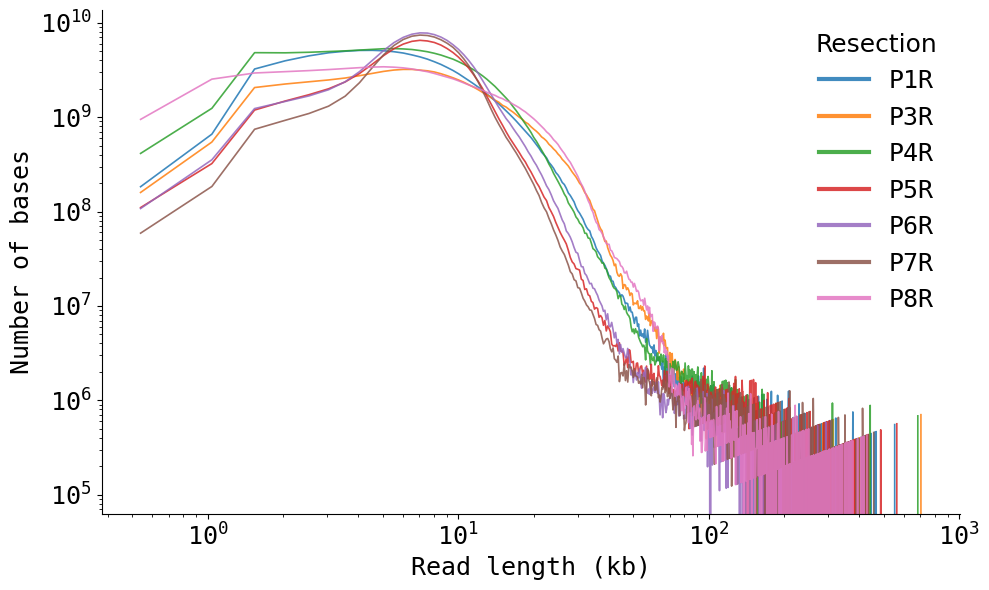

Saved: /path/to/data/NanoPlot/ONTWGS9//readcount_hist_10kb_R.pdf


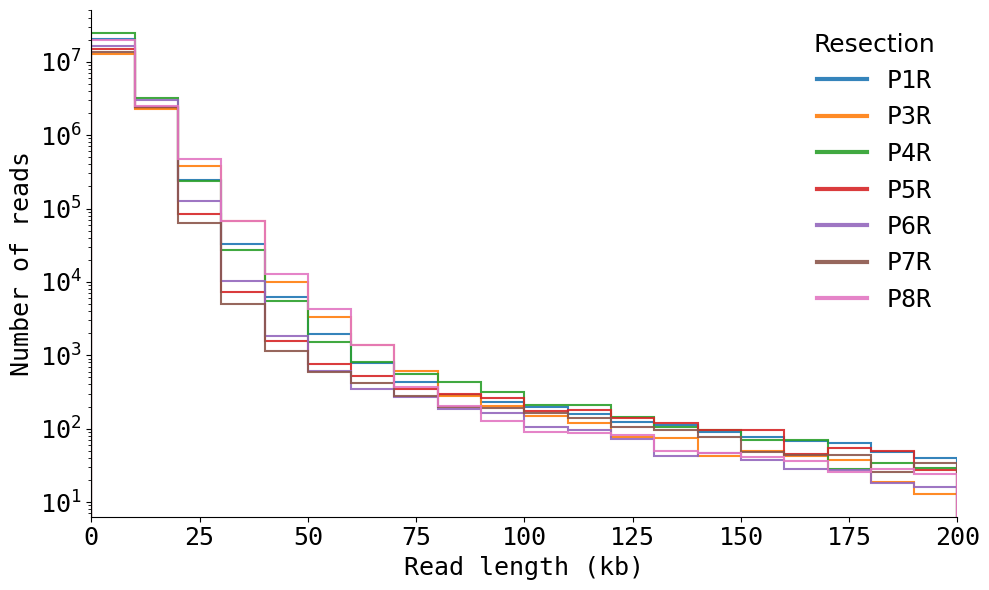

Saved: /path/to/data/NanoPlot/ONTWGS9//readlength_distribution_S_logx.pdf


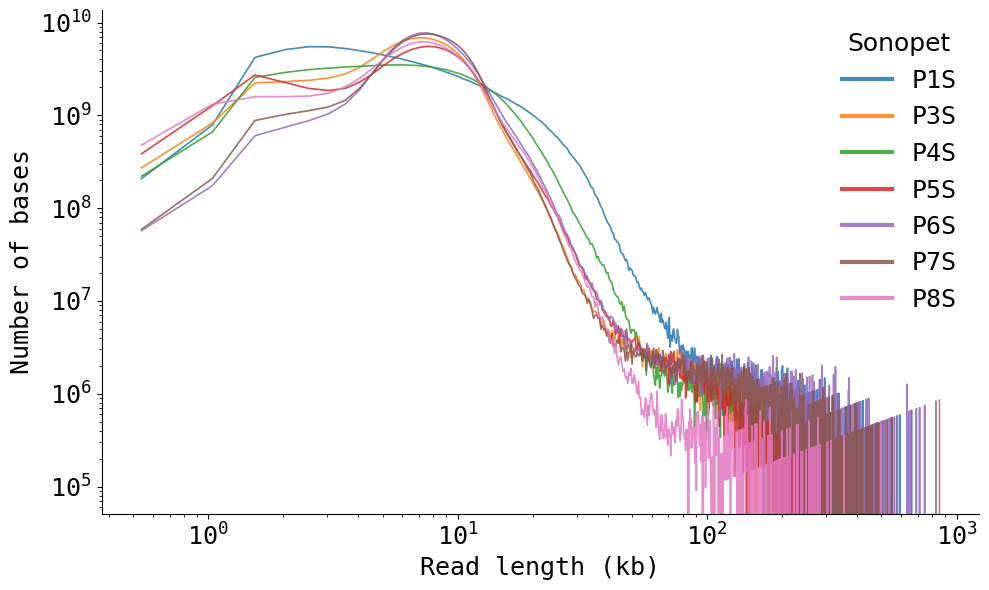

Saved: /path/to/data/NanoPlot/ONTWGS9//readcount_hist_10kb_S.pdf


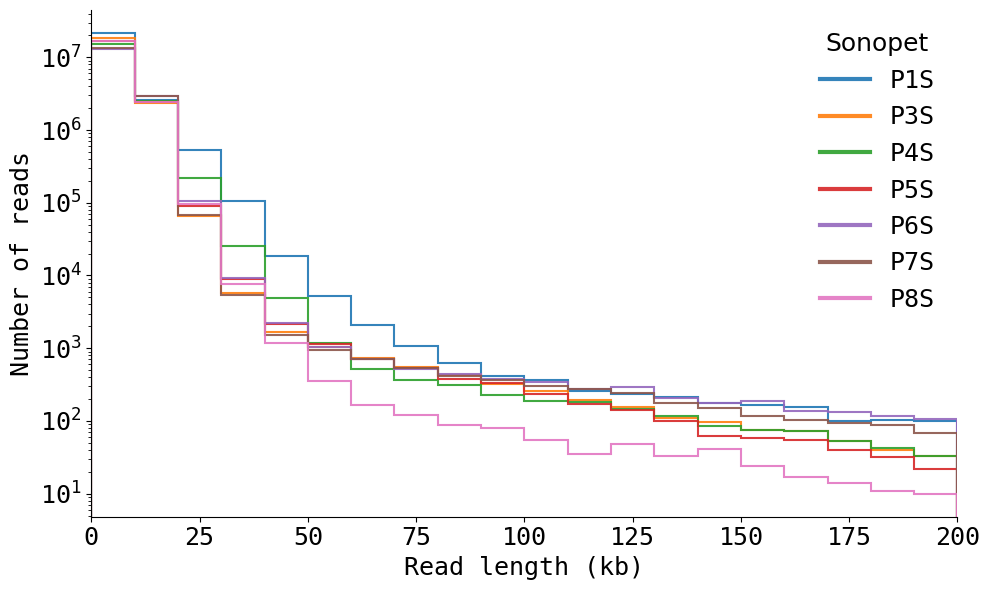


Resection
Sample           Reads                <10 kb             10-100 kb               >100 kb
P1R         22,826,886   20,220,537 (88.58%)    2,605,153 (11.41%)         1,196 (0.01%)
P3R         15,400,286   12,651,142 (82.15%)    2,748,443 (17.85%)           701 (0.00%)
P4R         28,062,811   24,610,792 (87.70%)    3,450,891 (12.30%)         1,128 (0.00%)
P5R         17,244,100   14,738,216 (85.47%)    2,504,670 (14.52%)         1,214 (0.01%)
P6R         19,610,841   16,471,811 (83.99%)    3,138,440 (16.00%)           590 (0.00%)
P7R         16,265,305   13,770,427 (84.66%)    2,493,924 (15.33%)           954 (0.01%)
P8R         22,913,864   19,878,053 (86.75%)    3,035,196 (13.25%)           615 (0.00%)
Mean        20,332,013   17,477,283 (85.61%)    2,853,817 (14.38%)           914 (0.00%)

Sonopet
Sample           Reads                <10 kb             10-100 kb               >100 kb
P1S         24,832,010   21,565,556 (86.85%)    3,263,995 (13.14%)         2,459 (0.01%)
P

In [12]:
def get_patient_colors(seqid_to_sr, exclude=(2,)):
    palette = plt.cm.tab10.colors
    patient_ids = sorted({int(v[:-1]) for v in seqid_to_sr.values()
                          if int(v[:-1]) not in exclude})
    return {p: palette[i % 10] for i, p in enumerate(patient_ids)}


def _find_nanoplot_html(html_dir, seqid, suffix):
    pattern = f"{html_dir}/ONTWGS9-{seqid}-*-NP01/ONTWGS9-{seqid}-*-NP01_{suffix}.html"
    matches = glob.glob(pattern)
    return matches[0] if matches else None


def _style_axes(ax, cfg, xlabel, ylabel):
    ax.set_xlabel(xlabel, fontsize=cfg["fontsize_label"], fontfamily=cfg["fontfamily"])
    ax.set_ylabel(ylabel, fontsize=cfg["fontsize_label"], fontfamily=cfg["fontfamily"])
    ax.tick_params(labelsize=cfg["fontsize_tick"])
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontfamily(cfg["fontfamily"])
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)


def _style_legend(ax, cfg, title):
    leg = ax.legend(frameon=False, ncol=1, loc="upper right",
                    title=title, title_fontsize=cfg["fontsize_label"],
                    prop={"family": cfg["fontfamily"], "size": cfg["fontsize_label"]})
    for line in leg.get_lines():
        line.set_linewidth(3)


def _rebin(x_bp, counts, bin_size_bp):
    """Sum counts from fine bins into coarser bins of bin_size_bp."""
    x_bp = np.asarray(x_bp, dtype=float)
    counts = np.asarray(counts, dtype=float)
    idx = np.floor(x_bp / bin_size_bp).astype(int)
    out = np.zeros(idx.max() + 1)
    np.add.at(out, idx, counts)
    left_edges = np.arange(len(out)) * bin_size_bp
    return left_edges, out


def _finish(save_path, show):
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
        print(f"Saved: {save_path}")
    if show:
        plt.show()


def plot_readlength_by_status(
    seqid_to_sr,
    status_filter,
    status_name,
    html_dir=HTML_DIR,
    cfg=PLOT_CFG,
    exclude_patients=(2,),
    logx=True,
    logy=True,
    xlim=None,
    save_path=None,
    show=True,
):
    """Number of bases vs read length, one line per sample."""
    colors = get_patient_colors(seqid_to_sr, exclude=exclude_patients)

    fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
    ax.set_facecolor("white")

    for seqid, sr in sorted(seqid_to_sr.items()):
        patient = int(sr[:-1])
        if patient in exclude_patients or sr[-1] != status_filter:
            continue
        label = f"P{sr}"
        path = _find_nanoplot_html(html_dir, seqid, "WeightedHistogramReadlength")
        if path is None:
            print(f"missing: {label}")
            continue

        x, y = parse_nanoplot_readlength_html(path)
        ax.plot(np.asarray(x) / 1000, y, color=colors[patient],
                linestyle="-", linewidth=1.2, label=label, alpha=0.85)

    _style_axes(ax, cfg, "Read length (kb)", "Number of bases")
    if logy:
        ax.set_yscale("log")
    if logx:
        ax.set_xscale("log")
    if xlim is not None:
        ax.set_xlim(*xlim)

    _style_legend(ax, cfg, status_name)
    _finish(save_path, show)
    return fig, ax


def plot_readcount_histogram(
    seqid_to_sr,
    status_filter,
    status_name,
    bin_size_kb=10,
    max_kb=200,
    filled=False,
    html_dir=HTML_DIR,
    cfg=PLOT_CFG,
    exclude_patients=(2,),
    logy=True,
    save_path=None,
    show=True,
):
    """Number of reads vs read length, fixed-width bins (default 10 kb)."""
    colors = get_patient_colors(seqid_to_sr, exclude=exclude_patients)
    bin_bp = bin_size_kb * 1000

    fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
    ax.set_facecolor("white")

    for seqid, sr in sorted(seqid_to_sr.items()):
        patient = int(sr[:-1])
        if patient in exclude_patients or sr[-1] != status_filter:
            continue
        label = f"P{sr}"
        path = _find_nanoplot_html(html_dir, seqid, "Non_weightedHistogramReadlength")
        if path is None:
            print(f"missing: {label}")
            continue

        x, y = parse_nanoplot_readlength_html(path)
        if y is None:
            edges = np.arange(0, np.max(x) + bin_bp, bin_bp)
            counts, edges = np.histogram(x, bins=edges)
        else:
            left, counts = _rebin(x, y, bin_bp)
            edges = np.append(left, left[-1] + bin_bp)

        if max_kb is not None:
            keep = edges[:-1] < max_kb * 1000
            counts = counts[keep]
            edges = edges[:len(counts) + 1]

        edges_kb = edges / 1000
        color = colors[patient]
        if filled:
            ax.stairs(counts, edges_kb, fill=True, color=color, alpha=0.25)
        ax.stairs(counts, edges_kb, color=color, linewidth=1.5,
                  alpha=0.9, label=label)

    _style_axes(ax, cfg, "Read length (kb)", "Number of reads")
    if logy:
        ax.set_yscale("log")
    if max_kb is not None:
        ax.set_xlim(0, max_kb)

    _style_legend(ax, cfg, status_name)
    _finish(save_path, show)
    return fig, ax


def _interval_counts(x, y, lo_bp, hi_bp):
    """Total reads and read counts in <lo, lo-hi, >=hi from a non-weighted histogram."""
    x = np.asarray(x, dtype=float)
    w = np.ones_like(x) if y is None else np.asarray(y, dtype=float)
    total = w.sum()
    below = w[x < lo_bp].sum()
    mid = w[(x >= lo_bp) & (x < hi_bp)].sum()
    above = w[x >= hi_bp].sum()
    return total, [below, mid, above]


def report_read_length_intervals(
    seqid_to_sr,
    html_dir=HTML_DIR,
    exclude_patients=(2,),
    statuses=(("R", "Resection"), ("S", "Sonopet")),
    lo_kb=10,
    hi_kb=100,
):
    """One table per status: reads (and %) below lo_kb, between lo_kb and hi_kb, above hi_kb."""
    heads = [f"<{lo_kb} kb", f"{lo_kb}-{hi_kb} kb", f">{hi_kb} kb"]
    cw = 22
    for status_filter, status_name in statuses:
        rows = []
        for seqid, sr in sorted(seqid_to_sr.items()):
            if int(sr[:-1]) in exclude_patients or sr[-1] != status_filter:
                continue
            path = _find_nanoplot_html(html_dir, seqid, "Non_weightedHistogramReadlength")
            if path is None:
                print(f"missing: P{sr}")
                continue
            x, y = parse_nanoplot_readlength_html(path)
            total, counts = _interval_counts(x, y, lo_kb * 1000, hi_kb * 1000)
            rows.append((f"P{sr}", total, counts))
        if not rows:
            continue

        print(f"\n{status_name}")
        print(f"{'Sample':<8}{'Reads':>14}" + "".join(f"{h:>{cw}}" for h in heads))
        for label, total, counts in rows:
            cells = "".join(f"{f'{n:,.0f} ({100 * n / total:.2f}%)':>{cw}}" for n in counts)
            print(f"{label:<8}{total:>14,.0f}" + cells)

        mean_total = np.mean([r[1] for r in rows])
        mean_counts = np.mean([r[2] for r in rows], axis=0)
        mean_pcts = np.mean([[100 * n / r[1] for n in r[2]] for r in rows], axis=0)
        cells = "".join(f"{f'{n:,.0f} ({p:.2f}%)':>{cw}}" for n, p in zip(mean_counts, mean_pcts))
        print(f"{'Mean':<8}{mean_total:>14,.0f}" + cells)


for status_filter, status_name in [("R", "Resection"), ("S", "Sonopet")]:
    plot_readlength_by_status(
        SEQID_TO_SR, status_filter, status_name,
        save_path=f"{HTML_DIR}/readlength_distribution_{status_filter}_logx.pdf",
    )
    plot_readcount_histogram(
        SEQID_TO_SR, status_filter, status_name, bin_size_kb=10,
        save_path=f"{HTML_DIR}/readcount_hist_10kb_{status_filter}.pdf",
    )

report_read_length_intervals(SEQID_TO_SR)

In [13]:
from pathlib import Path
import os

def plot_kde_sample(path, save_dir, seqid, sr, cfg=PLOT_CFG):
    with open(path) as f:
        content = f.read()
    match = re.search(r'Plotly\.newPlot\(\s*"[^"]+",\s*(\[.*?\]),\s*\{', content, re.DOTALL)
    traces = json.loads(match.group(1))
    kde = next(t for t in traces if t.get("type") == "histogram2dcontour")
    x = np.array(kde["x"])  # log10 read length
    y = np.array(kde["y"])  # quality

    label = f"P{sr}"

    fig, ax = plt.subplots(figsize=(6, 4), facecolor="white")

    XLIM = (1, 5)
    YLIM = (0, 40)

    # bin over the FIXED axis range so the contour grid fills the whole panel
    # (identical bins for every sample → cross-sample comparable)
    h, xedges, yedges = np.histogram2d(x, y, bins=80, range=[XLIM, YLIM])
    xc = (xedges[:-1] + xedges[1:]) / 2
    yc = (yedges[:-1] + yedges[1:]) / 2
    levels = np.linspace(0, h.T.max(), 13)  # start from 0 → fills full plot area

    ax.contourf(xc, yc, h.T, levels=levels, cmap="Blues")
    ax.contour( xc, yc, h.T, levels=levels, colors="steelblue", linewidths=0.4, alpha=0.6)

    ax.set_xlim(*XLIM)
    ax.set_ylim(*YLIM)

    ax.set_xlabel(r"Read length ($\log_{10}$ bp)", fontsize=cfg["fontsize_label"],
                  fontfamily=cfg["fontfamily"])
    ax.set_ylabel("Read quality", fontsize=cfg["fontsize_label"],
                  fontfamily=cfg["fontfamily"])
    ax.set_title(label, fontsize=cfg["fontsize_title"], fontfamily=cfg["fontfamily"])
    ax.tick_params(labelsize=cfg["fontsize_tick"])
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontfamily(cfg["fontfamily"])
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

    plt.tight_layout()
    fname = os.path.join(save_dir, f"P{sr}_kde.pdf")
    plt.savefig(fname, bbox_inches="tight", facecolor="white")
    plt.close()
    print(f"Saved: {fname}")


# ── run across all samples ─────────────────────────────────────────────────────
save_dir = "/path/to/data/NanoPlot/ONTWGS9/LengthvsQuality"
os.makedirs(save_dir, exist_ok=True)

for seqid, sr in sorted(SEQID_TO_SR.items()):
    patient = int(sr[:-1])
    if patient == 2:
        continue
    pattern = (f"{HTML_DIR}/ONTWGS9-{seqid}-*-NP01/"
               f"ONTWGS9-{seqid}-*-NP01_LengthvsQualityScatterPlot_loglength_kde.html")
    matches = glob.glob(pattern)
    if not matches:
        print(f"missing: P{sr}")
        continue
    plot_kde_sample(matches[0], save_dir, seqid, sr)

Saved: /path/to/data/NanoPlot/ONTWGS9/LengthvsQuality/P1S_kde.pdf
Saved: /path/to/data/NanoPlot/ONTWGS9/LengthvsQuality/P1R_kde.pdf
Saved: /path/to/data/NanoPlot/ONTWGS9/LengthvsQuality/P3R_kde.pdf
Saved: /path/to/data/NanoPlot/ONTWGS9/LengthvsQuality/P3S_kde.pdf
Saved: /path/to/data/NanoPlot/ONTWGS9/LengthvsQuality/P4R_kde.pdf
Saved: /path/to/data/NanoPlot/ONTWGS9/LengthvsQuality/P4S_kde.pdf
Saved: /path/to/data/NanoPlot/ONTWGS9/LengthvsQuality/P5R_kde.pdf
Saved: /path/to/data/NanoPlot/ONTWGS9/LengthvsQuality/P5S_kde.pdf
Saved: /path/to/data/NanoPlot/ONTWGS9/LengthvsQuality/P6R_kde.pdf
Saved: /path/to/data/NanoPlot/ONTWGS9/LengthvsQuality/P6S_kde.pdf
Saved: /path/to/data/NanoPlot/ONTWGS9/LengthvsQuality/P7R_kde.pdf
Saved: /path/to/data/NanoPlot/ONTWGS9/LengthvsQuality/P7S_kde.pdf
Saved: /path/to/data/NanoPlot/ONTWGS9/LengthvsQuality/P8R_kde.pdf
Saved: /path/to/data/NanoPlot/ONTWGS9/LengthvsQuality/P8S_kde.pdf


In [22]:
path = glob.glob(f"{HTML_DIR}/ONTWGS9-1-*-NP01/ONTWGS9-1-*-NP01_LengthvsQualityScatterPlot_loglength_kde.html")[0]
with open(path) as f:
    content = f.read()
match = re.search(r'Plotly\.newPlot\(\s*"[^"]+",\s*(\[.*?\]),\s*\{', content, re.DOTALL)
traces = json.loads(match.group(1))
kde = next(t for t in traces if t.get("type") == "histogram2dcontour")
x = np.array(kde["x"])
print(f"x min={x.min():.1f}, max={x.max():.1f}, mean={x.mean():.1f}")

x min=1.8, max=5.0, mean=3.5
